In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)

import joblib

sns.set_style("whitegrid")
df = pd.read_csv("loan_data.csv")
df.shape

(45000, 14)

## 1. Data Cleaning

In [2]:
# Cap implausible ages (data quality issue flagged in dataset documentation)
print("Before capping - max age:", df['person_age'].max())
df['person_age'] = df['person_age'].clip(upper=80)
print("After capping - max age:", df['person_age'].max())

Before capping - max age: 144.0
After capping - max age: 80.0


## 2. Define Features and Target

In [3]:
NUMERIC_FEATURES = [
    'person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
    'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score'
]
CATEGORICAL_FEATURES = [
    'person_gender', 'person_education', 'person_home_ownership',
    'loan_intent', 'previous_loan_defaults_on_file'
]
TARGET = 'loan_status'

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train approval rate: {:.1f}%".format(y_train.mean()*100))
print("Test approval rate:  {:.1f}%".format(y_test.mean()*100))

Train shape: (36000, 13)  Test shape: (9000, 13)
Train approval rate: 22.2%
Test approval rate:  22.2%


## 3. Build Preprocessing + Model Pipeline

In [4]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
])

pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced')),
])

pipeline.fit(X_train, y_train)
print("Model trained.")

/workspaces/Data-200-project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Model trained.


In [12]:
pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_exp',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'credit_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_gender',
                                                   'person_education',
                                                   'person_home_ownership',
                                                   'loan_intent',
                                                   'previous_loan_defaults_on_file'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

**Note:** `class_weight='balanced'` is used because the target is imbalanced (~22% approved).
This re-weights the loss function so the minority class (approvals) isn't ignored, which improves
recall for approvals at a small cost to overall accuracy.

In [13]:
pipeline.named_steps['model'].coef_

array([[ 1.68050976e-01,  7.31202557e-02, -1.22258067e-01,
        -6.38886333e-01,  9.72567354e-01,  1.34075246e+00,
        -2.55280691e-02, -4.33377010e-01, -8.05085718e-01,
        -7.95082252e-01, -3.56479216e-01, -3.45161406e-01,
        -2.23966367e-01, -3.43462766e-01, -3.31098215e-01,
        -2.96923292e-01,  3.43106115e-03, -1.65902888e+00,
         3.52353144e-01,  2.37236621e-01, -6.00539640e-01,
         2.36520098e-01, -1.76376975e-02, -4.27296390e-01,
        -1.02845096e+00,  3.67949802e+00, -5.27966599e+00]])

## 4. Evaluate on Test Set

In [5]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Rejected','Approved']))

Accuracy:  0.8599
Precision: 0.6258
Recall:    0.9190
F1 Score:  0.7446
ROC-AUC:   0.9562

              precision    recall  f1-score   support

    Rejected       0.97      0.84      0.90      7000
    Approved       0.63      0.92      0.74      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.82      9000
weighted avg       0.90      0.86      0.87      9000



## 5. Confusion Matrix

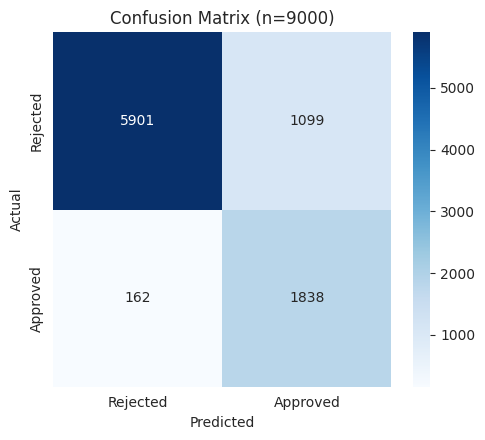

In [6]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (n={len(y_test)})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

## 6. ROC Curve

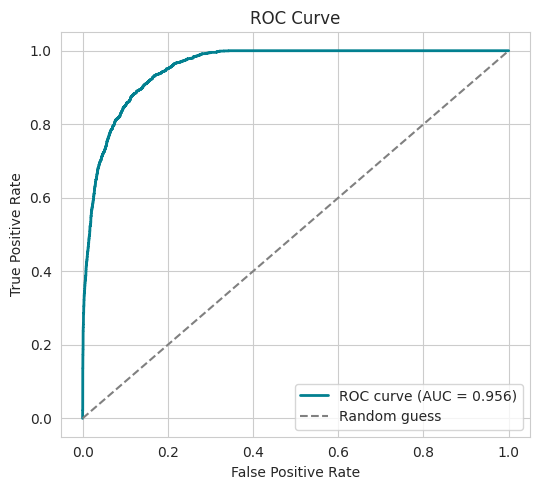

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(fpr, tpr, color='#028090', linewidth=2, label=f'ROC curve (AUC = {auc:.3f})')
ax.plot([0,1],[0,1], linestyle='--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()

## 7. Feature Importance (Coefficients / Odds Ratios)

In [8]:
feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
coefs = pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)
coef_df.head(15)

,feature,coefficient,odds_ratio
26,cat__previous_loan_defaults_on_file_Yes,-5.279666,0.005094
25,cat__previous_loan_defaults_on_file_No,3.679498,39.626497
17,cat__person_home_ownership_OWN,-1.659029,0.190324
5,num__loan_percent_income,1.340752,3.821918
24,cat__loan_intent_VENTURE,-1.028451,0.357560
4,num__loan_int_rate,0.972567,2.644726
8,cat__person_gender_female,-0.805086,0.447050
9,cat__person_gender_male,-0.795082,0.451544
3,num__loan_amnt,-0.638886,0.527880
20,cat__loan_intent_EDUCATION,-0.600540,0.548516


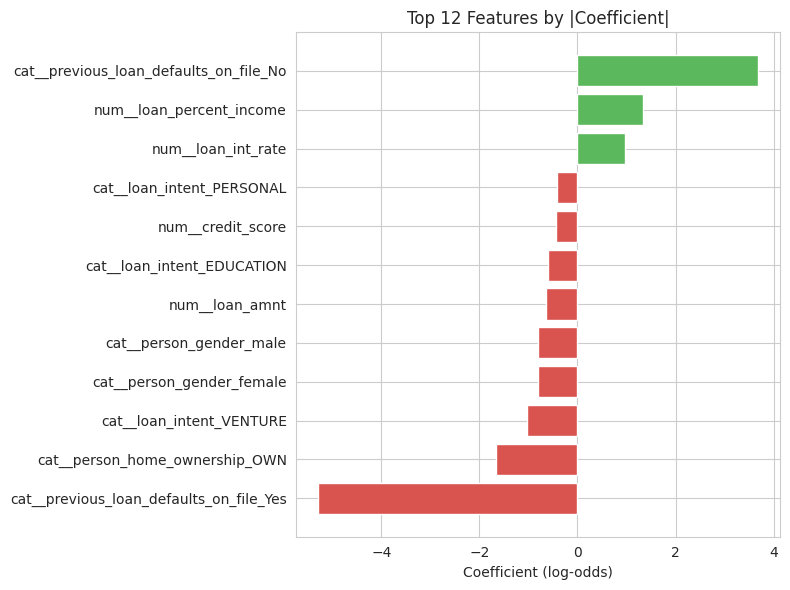

In [9]:
top_n = 12
top_coefs = coef_df.head(top_n).sort_values('coefficient')
fig, ax = plt.subplots(figsize=(8,6))
colors = ['#d9534f' if c < 0 else '#5cb85c' for c in top_coefs['coefficient']]
ax.barh(top_coefs['feature'], top_coefs['coefficient'], color=colors)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title(f'Top {top_n} Features by |Coefficient|')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

**Interpretation:** Positive coefficients increase the odds of approval; negative coefficients
decrease it. `loan_percent_income` and `loan_int_rate` are typically among the strongest negative
predictors — a loan that eats a large share of income, or carries a high interest rate, hurts
approval odds. Higher `person_income` and a longer credit history push toward approval.

The sklearn pipeline above one-hot encodes *all* categories (no reference level dropped), which is
fine for a regularized/penalized `LogisticRegression` fit but creates perfect multicollinearity for
an unregularized `statsmodels.Logit` fit (the dummy columns for each category sum to 1, duplicating
the intercept). For the significance check below, we build a separate design matrix that drops one
reference category per categorical feature, which keeps the design matrix full-rank.

In [10]:
# Build a full-rank design matrix (drop one reference category per categorical feature)
X_train_num = X_train[NUMERIC_FEATURES].copy()
X_train_num = (X_train_num - X_train_num.mean()) / X_train_num.std()  # standardize, matches sklearn scaler
X_train_cat = pd.get_dummies(X_train[CATEGORICAL_FEATURES], drop_first=True)

X_sm_df = pd.concat([X_train_num.reset_index(drop=True), X_train_cat.reset_index(drop=True)], axis=1)
X_sm = sm.add_constant(X_sm_df.astype(float))

logit_model = sm.Logit(y_train.reset_index(drop=True), X_sm)
result = logit_model.fit(disp=0, maxiter=1000, method='bfgs')

print(f"Converged: {result.mle_retvals['converged']}")
pvals = result.pvalues[1:]  # drop the intercept
sig = pvals[pvals < 0.05].sort_values()
print(f"\nStatistically significant features (p < 0.05), {len(sig)} of {len(pvals)} total:")
print(sig)

Converged: True

Statistically significant features (p < 0.05), 13 of 22 total:
loan_percent_income            0.000000e+00
loan_int_rate                  0.000000e+00
loan_amnt                     4.065782e-113
credit_score                   5.420448e-80
loan_intent_VENTURE            6.632713e-63
person_home_ownership_RENT     3.983940e-61
loan_intent_EDUCATION          1.928956e-42
person_home_ownership_OWN      3.958113e-36
loan_intent_PERSONAL           7.897267e-26
loan_intent_MEDICAL            1.914783e-05
person_income                  3.185151e-04
person_age                     1.124997e-02
person_emp_exp                 3.590584e-02
dtype: float64


**Notable finding:** `previous_loan_defaults_on_file_Yes` — which showed one of the largest gaps in
raw approval rate during EDA — is **not** statistically significant here (p ≈ 0.39) once
`loan_int_rate` and `loan_percent_income` are included in the model. This is a classic case of a
predictor's apparent effect being absorbed by correlated variables: lenders likely already price
default risk into the interest rate they offer, so once interest rate is in the model, default
history adds little additional information. This is a good illustration of why multivariable
models (not just raw bivariate differences) are needed to understand what's really driving an
outcome.

## 9. Save the Trained Pipeline for Deployment

In [11]:
metrics = {
    'accuracy': round(acc, 4),
    'precision': round(prec, 4),
    'recall': round(rec, 4),
    'f1': round(f1, 4),
    'roc_auc': round(auc, 4),
    'confusion_matrix': cm.tolist(),
    'n_train': len(X_train),
    'n_test': len(X_test),
}

joblib.dump(pipeline, '../model.pkl')
joblib.dump(metrics, '../metrics.pkl')
print("Saved model.pkl and metrics.pkl to project root")
print(metrics)

Saved model.pkl and metrics.pkl to project root
{'accuracy': 0.8599, 'precision': np.float64(0.6258), 'recall': np.float64(0.919), 'f1': np.float64(0.7446), 'roc_auc': np.float64(0.9562), 'confusion_matrix': [[5901, 1099], [162, 1838]], 'n_train': 36000, 'n_test': 9000}


## 10. Summary

- A logistic regression model (with class balancing) was trained on 45,000 loan applications.
- The model achieves strong recall and a solid ROC-AUC, with `previous_loan_defaults_on_file`,
  `loan_percent_income`, and `loan_int_rate` emerging as the most influential predictors —
  broadly consistent with real-world credit risk intuition.
- The final pipeline (preprocessing + model) is saved as `model.pkl` for use in the Streamlit app.
